# Оценка стоимости подержанных автомобилей для AutoValue AI

Проект строит модель, которая по характеристикам автомобиля предсказывает его рыночную стоимость. Цель - заменить ручную оценку экспертов и масштабировать сервис до 10 000 заявок в день.

## Содержание
1. <a href="#problem_statement">Постановка задачи</a>
1. <a href="#eda">EDA (Экспресс-анализ данных)</a>
1. <a href="#preprocessing">Предобработка данных</a>
1. <a href="#baseline_models">Обучение базовых моделей</a>
1. <a href="#tuning">Тюнинг гиперпараметров</a>
1. <a href="#interpretation">Интерпретация и бизнес-анализ</a>
1. <a href="#final_test">Финальная проверка</a>
1. <a href="#conclusion">Выводы и финальный вердикт</a>


<a id="problem_statement"></a>

## Постановка задачи машинного обучения


### Бизнес-контекст

AutoValue AI выкупает подержанные автомобили у частных лиц. Клиент заполняет анкету в приложении, алгоритм за секунду выдает цену, и если клиента устраивает - он приезжает в офис и получает деньги на счет.

Раньше этим занимались 50 оценщиков вручную. Это медленно, дорого и не масштабируется.

Ошибка модели стоит денег в обе стороны: завысить цену - купим неликвид, занизить - клиент уйдет к конкурентам.

### Цель исследования

Нужно построить модель, которая по характеристикам автомобиля предсказывает его рыночную стоимость в рублях.

### Постановка задачи машинного обучения

Это задача регрессии. Целевая переменная - price_rub.

В данных 8000 реальных сделок, которые провели эксперты компании. Признаки:

- характеристики автомобиля: марка, год, пробег, объем двигателя, тип топлива, коробка передач;
- история владения: количество владельцев, сервисная книжка, ДТП;
- прочее: цвет, страховка, регион.

### Какие модели будем сравнивать

Задача - провести турнир между тремя библиотеками градиентного бустинга и выбрать лучшую для продакшена:

- XGBoost;
- CatBoost;
- LightGBM.

Каждая модель сначала обучается с дефолтными параметрами, потом тюнингуется через Optuna.

### Метрики

Математические метрики для сравнения моделей:

- MAE - средняя абсолютная ошибка в рублях, основная метрика оптимизации;
- RMSE - сильнее штрафует за крупные ошибки;
- R2 - доля объясненной дисперсии.

Бизнес-метрики для оценки финансовых рисков:

- Overpricing Rate - доля случаев, где модель завысила цену больше чем на 20%. Это прямой убыток при перепродаже;
- Underpricing Loss - суммарная разница в случаях, где модель занизила цену больше чем на 20%. Это упущеная выручка.

### Что нужно получить в итоге

Нужно выбрать лучшую библиотеку, подобрать гиперпараметры и проверить модель на отложенной тестовой выборке ds_s16_test_data.csv.

Дополнительно - проанализировать важность признаков через SHAP и найти марки и регионы, где модель ошибается чаще всего.

<a id="eda"></a>

# **Часть 1. EDA (Экспресс-анализ данных)**

Проведите краткое исследование, чтобы лучше понимать данные.

**Задание 1.1:**

* Данные: загрузите `ds_s16_train_data.csv` (обучение) и `ds_s16_test_data.csv` (финальный тест). Обратите внимание на то, как прописать путь к данным: `/datasets/ds_s16_train_data.csv` и `/datasets/ds_s16_test_data.csv`
* Проведите краткий EDA: изучите распределение целевой переменной (`price_rub`), проверьте корреляции.

---

### Подготовка окружения

Загрзим необходимые зависимости и импортируем классы. Также определим утилитарные классы, которые помогают в различных частях исследования - от загрузки данных до моделирования.

In [527]:
! rm requirements.txt

In [528]:
from pathlib import Path

requirements_file = Path('requirements.txt')
requirements = [
    'scikit-learn==1.6.1',
    'seaborn==0.13.2',
    'optuna==4.8.0',
    'humanfriendly==10.0',
    'phik==0.12.5',
    'xgboost==3.2.0',
    'catboost==1.2.10',
    'lightgbm==4.6.0',
    'shap==0.51.0',
]
if not requirements_file.exists():
    with open(requirements_file, 'w') as f:
        f.write('\n'.join(requirements))
        print(f'{requirements_file} created')
else:
    print(f'{requirements_file} exists')

print('Установка зависимостей...')
!pip install -r requirements.txt
print('Зависимости успешно установлены!')


requirements.txt created
Установка зависимостей...
  Using cached cloudpickle-3.1.2-py3-none-any.whl.metadata (7.1 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 562.3/562.3 kB 1.1 MB/s eta 0:00:00-:--:--
Using cached cloudpickle-3.1.2-py3-none-any.whl (22 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.2/37.2 MB 355.5 kB/s eta 0:00:0000:0100:03
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 399.9 kB/s eta 0:00:0000:0100:01

[notice] A new release of pip is available: 25.0 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Зависимости успешно установлены!


In [530]:
import os
import requests
import optuna
import time
import shap

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from sklearn.pipeline import Pipeline
from phik import phik_matrix

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

from sklearn.model_selection import KFold
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import cross_validate, cross_val_score
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    make_scorer,
)

from humanfriendly import format_size


Подготовка параметров тетрадки и утилит:

In [516]:
TARGET_COL_NAME = 'price_rub'
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option('display.max_columns', None) # выводить все колонки
pd.set_option('display.max_colwidth', 500) # выводить больше символов в ячейке

#### Заргузка ресурсов
class ResourceLoader:
    """
    Класс для безопасной загрузки ресурсов по http: датасет и произвольный файл.
    Если файл уже был скачан ранее и сохранен в локальной файловой системе, то
    загрузка из удаленного источника не производится.

    Для загрузки датасета: load_dataset(dataset_url, local_file, local_path='datasets'): dataframe
    Для загрузки файла: load_resource(resource_url, local_path, local_file): path
    """

    def __init__(self):
        pass

    def load_resource(self, resource_url, local_path, local_file):
        local_resource_file = f'{local_path}/{local_file}'
        if os.path.exists(local_resource_file):
            print(f'Файл {local_resource_file} уже существует')
            return local_resource_file

        os.makedirs(local_path, exist_ok=True)
        print(f'Загружаем файл из {resource_url}')
        response = requests.get(resource_url)
        if response.status_code == 200:
            with open(local_resource_file, 'wb') as f:
                f.write(response.content)
            file_size = format_size(os.path.getsize(local_resource_file))
            print(f'Файл успешно загружен в {local_resource_file},',
                  f'размер файла: {file_size}')
            return local_resource_file
        else:
            raise NetworkError(f'Ошибка при загрузке файла: {response.status_code}')


    def load_dataset(
        self,
        dataset_url,
        local_file = None,
        local_path='datasets',
        sep=',',
        decimal='.'
    ):
        if local_file is None:
            local_file = dataset_url.split('/')[-1]
        local_dataset_file = f'{local_path}/{local_file}'
        remote_dataset_url = dataset_url
        def read_dataset_csv():
            return pd.read_csv(local_dataset_file, sep=sep, decimal=decimal)

        try:
            df = read_dataset_csv()
            print(f'Датасет успешно загружен из {local_dataset_file}')
        except FileNotFoundError:
            self.load_resource(remote_dataset_url, local_path, local_file)
            df = read_dataset_csv()

        print(f'Размер загруженного датасета: {df.shape[0]} строк, {df.shape[1]} столбцов', )
        return df

#### EDA
class CorrelationDisplayer:
    """
    Класс для отображения матрицы корреляций признаков в разных видах
    """
    def __init__(self, corr_matrix):
        self.corr_matrix = corr_matrix

    def get_corr_matrix(self):
        return self.corr_matrix

    def _subset_corr_matrix(self, subset):
        subset_cols = self.corr_matrix.columns if subset is None else subset
        return self.corr_matrix.loc[subset_cols, subset_cols]

    def draw_corr_matrix_full(
            self,
            digits=2,
            title='Матрица корреляций признаков',
            subtitle=None,
            figsize=(16, 10),
            subset=None,
    ):
        plt.subplots(figsize=figsize)
        matrix = self._subset_corr_matrix(subset)
        sns.heatmap(matrix.round(digits), annot=True, cmap='coolwarm', linewidths=0.5)
        plt.title(title + "\n" + subtitle if subtitle else title)
        plt.show()


    def draw_corr_matrix_with_target(
            self,
            target_col,
            title='Матрица корреляций с таргетом',
            subtitle=None,
            figsize=(16, 10),
    ):
        plt.subplots(figsize=figsize)
        data_heatmap = self.corr_matrix.loc[
            self.corr_matrix.index != target_col
        ][[target_col]].sort_values(by=target_col, ascending=False)
        sns.heatmap(data_heatmap, annot=True, cmap='coolwarm', linewidths=0.5)
        plt.title(title + "\n" + subtitle if subtitle else title)
        plt.show()

    def draw_pair_correlations(self, subset=None, figsize=(16, 10), corr_threshold=0.9):
        # преобразуем матрицу корреляции в датафрейм попарных корреляций
        # feature_1+feature_2 -> correlation
        matrix = self._subset_corr_matrix(subset)
        pair_correlations = matrix \
            .stack() \
            .reset_index() \
            .rename(columns={
                'level_0': 'feature1',
                'level_1': 'feature2',
                0: 'correlation'
            }) \
            .query('feature1 != feature2') \
            .sort_values(by='correlation', ascending=False) \

        def order_pair(row):
            if row['feature1'] > row['feature2']:
                return row['feature2'] + '/' + row['feature1']
            else:
                return row['feature1'] + '/' + row['feature2']

        pair_correlations['order_pair'] = pair_correlations.apply(order_pair, axis=1)
        pair_correlations = pair_correlations.drop(columns=['feature1', 'feature2'])
        pair_correlations = pair_correlations.drop_duplicates().reset_index(drop=True)
        pair_correlations = pair_correlations.query('correlation > @corr_threshold')
        pair_correlations = pair_correlations.sort_values(by='correlation')
        pair_correlations.plot(
            x='order_pair',
            y='correlation',
            xlabel='Значение корреляции',
            ylabel='Пара признаков',
            kind='barh',
            legend=False,
            figsize=figsize,
            grid=True,
        )
        plt.title('Попарные корреляции')
        plt.show()
        return pair_correlations.sort_values(by='correlation', ascending=False).reset_index(drop=True)

class EDAHelper:
    def __init__(self):
        pass

    def df_info(self, df, name = '', n_samples=3):
        print('-'*50)
        print(f'Описание датасета {name}:')
        print(f'Датасет {name} содержит {df.shape[0]} строк и {df.shape[1]} столбцов.')
        print(f'Размер датасета {name} в памяти: {format_size(df.memory_usage().sum())}')
        print('-'*50)
        print(f'Данные датасета {name}:')
        print('-'*50)
        display(
            pd.concat([
                df.head(n_samples).assign(place='head'),
                df.sample(n_samples, random_state=RANDOM_STATE).assign(place='random'),
                df.tail(n_samples).assign(place='tail'),
            ]).sort_index()
        )
        print('-'*50)

        print(df.info())
        nan_counts = self.na_info(df)
        if (len(nan_counts) > 0):
            display(nan_counts)
        else:
            print(f'В датасете {name} нет пропущенных значений')

    def convert_to_datetime(self, df, column, format='%Y-%m-%d', print_time_range=True):
        df[column] = pd.to_datetime(df[column], format=format)
        if print_time_range:
            self.print_time_range(df, column)
        return df


    def print_time_range(self, df, datetime_column):
        # определим временную ось таблицы:
        start_date = df[datetime_column].min()
        end_date = df[datetime_column].max()
        diff = int((end_date - start_date) / np.timedelta64(1, 'D'))
        diff_years = diff / 365.25

        print(f'Данные в "{datetime_column}" представлены за период {diff} дн. ({diff_years:.1f} л.): {start_date} - {end_date}')

    def box_hist(self, df, column, title=None, bins=20, hue=None, kde=True, stat='density'):
        f, (ax_box, ax_hist) = plt.subplots(2, sharex=True, gridspec_kw={"height_ratios": (.15, .85)})
        display(pd.DataFrame(df[[column]].describe().T))
        sns.boxplot(df[column], orient='h', ax=ax_box)
        sns.histplot(data=df, x=column, ax=ax_hist, bins=bins, hue=hue, kde=kde, stat=stat)

        f.suptitle(f'Распределение признака {column}' if title is None else title)
        if stat == 'density':
            ylabel = 'Плотность распределения'
        elif stat == 'count':
            ylabel = 'Количество'
        elif stat == 'frequecy':
            ylabel = 'Частота'
        else:
            ylabel = 'Доля'

        ax_box.set(xlabel='')
        ax_hist.set(
            xlabel=f'Значения признака {column}',
            ylabel=ylabel
        )
        plt.show()

    def time_line(self, df, datetime_column, y_column, ylabel=None):
        if ylabel is None:
            ylabel = y_column

        df.plot(
            kind='line',
            x=datetime_column,
            y=y_column,
            xlabel='Дата',
            ylabel=ylabel,
            title=f'Завимость признака "{y_column}" от времени',
            legend=False,
        )
        plt.show()

    def drop_duplicates(self, df, subset=None):
        ndups = df.duplicated(subset=subset).sum()
        print(f'Найдено {ndups} дубликатов по {"всем" if subset is None else subset} столбцам')
        if ndups > 0:
            df_orig = df.copy()
            df.drop_duplicates(subset=subset, inplace=True)
            diff = len(df_orig) - len(df)
            diff_pct = diff / len(df_orig) * 100
            print(f'Удалено {diff} строк ({diff_pct:.1f}%) из {len(df_orig)}')
        else:
            print('Дубликатов не обнаружено')

    def na_info(self, df, round_digits=1):
        '''
        Возвращает таблицу с количеством и процентом пропусков в столбцах датасета.
        '''
        count_na_name = 'Количество пропусков'
        res = pd.DataFrame({
            'Количество строк': len(df),
            count_na_name: df.isna().sum(),
            'Процент пропусков': round(df.isna().mean()*100, round_digits)
        }).sort_values(by=count_na_name, ascending=False)
        return res.query(f'`{count_na_name}` > 0').reset_index()


    # Уникальные значения всех категориальных признаков
    def get_unique_values(self, df, top_n=5, cat_columns=[]):
        print('Уникальные значения всех категориальных признаков:\n')
        data = []
        columns = cat_columns if cat_columns else df.select_dtypes(include=['object']).columns
        for col in columns:
            unique_vals = df[col].unique().tolist()
            unique_vals.sort()
            top_n_vals = ', '.join(unique_vals[:top_n])
            unique_val_str =  top_n_vals if len(unique_vals) <= top_n else f'{top_n_vals}, ...'
            num_of_unique_vals = df[col].nunique()
            data.append({
                'feature': col,
                'num_of_unique_vals': num_of_unique_vals,
                'unique_vals': unique_val_str,
            })
        return pd.DataFrame(data)

### Обучение модели
class ModelTrainHelper:
    def __init__(self):
        self.best_estimator_ = None
        pass

    def do_cross_validation(
            self,
            pipelines,
            X_train_val, y_train_val,
            scoring,
            metrics_df_list = [],
            return_train_score=False,
            cv=5,
    ):

        cv_results_by_model = {}
        # Обучение моделей
        for name, p in pipelines.items():
            start_time = time.time()
            cv_results = cross_validate(
                estimator=p['model'],
                X=X_train_val,
                y=y_train_val,
                scoring=scoring,
                return_train_score=return_train_score,
                return_estimator=True,
                cv=cv,
                verbose=0,
                n_jobs=-1,
                params=p.get('fit_params'),
            )
            end_time = time.time()
            wall_time = end_time - start_time
            print(f'Обучение "{name}" заняло {wall_time:.2f} секунд')
            cv_results['wall_time_sec'] = wall_time
            cv_results_by_model[name] = cv_results

        def non_negative_metric(metric):
            if metric.startswith('neg_'):
                return (True, metric[len('_neg'):])
            else:
                return (False, metric)

        is_neg_main_metric, main_metric = non_negative_metric(scoring[0])

        # Сохранение результатов в сводную таблицу:
        def append_metrics(result_metrics, model_name, cv_results, test_or_train='test', scoring=[]):
            metrics_dict = {}

            metrics_dict['model_name'] = model_name
            metrics_dict['wall_time_sec'] = cv_results.get('wall_time_sec', 0)
            metrics_dict = metrics_dict | {
                metric: np.mean(cv_results[f'{test_or_train}_{metric}']) for metric in scoring
            }
            # for metric in scoring:
            #     print(metric, cv_results[f'{test_or_train}_{metric}'])
            # add standard deviation
            # metrics_dict = metrics_dict | {
            #     f'{metric}_std': np.std(-cv_results[f'{test_or_train}_{metric}']) for metric in scoring
            # }

            keys = list(metrics_dict.keys())
            for metric in keys:
                # invert sign for neg metrics like neg_mean_squared_error
                # and rename metrics withoud neg
                if metric.startswith('neg_'):
                    metrics_dict[metric[len('neg_'):]] = metrics_dict[metric] * -1 if not metric.endswith('_std') else 1
                    metrics_dict.pop(metric)

            result_metrics.append(metrics_dict)
            return metrics_dict

        for model_name, model_cv_results in cv_results_by_model.items():
            append_metrics(
                metrics_df_list,
                model_name,
                model_cv_results,
                scoring=scoring,
            )
            if return_train_score and 'dummy' not in model_name.lower():
                append_metrics(
                    metrics_df_list,
                    f'{model_name} (train)',
                    model_cv_results,
                    test_or_train='train',
                    scoring=scoring,
                )

        metrics_df = pd.DataFrame(metrics_df_list) \
            .sort_values(by=main_metric, ascending=is_neg_main_metric)

        metrics_df.set_index('model_name', inplace=True)
        return metrics_df.sort_index(axis=1)

    def confusion_matrix_displayed(self, y_true, y_pred, true_desc='Уйдет', false_desc='Останется'):
        cm = confusion_matrix(y_true, y_pred)

        # Визуализируем матрицу
        plt.figure(figsize=(8, 6))

        # Отображаем матрицу как изображение
        im = plt.imshow(cm, interpolation='nearest', cmap='Blues')
        plt.colorbar(im)

        # Добавляем подписи осей
        plt.xlabel('Предсказанные классы', fontsize=12)
        plt.ylabel('Истинные классы', fontsize=12)
        plt.title('Матрица ошибок', fontsize=14)

        # Настраиваем метки на осях
        tick_marks = [0, 1]
        plt.xticks(tick_marks, [false_desc, true_desc])
        plt.yticks(tick_marks, [false_desc, true_desc])

        # Матрица имеет структуру:
        matrix_desc = [
            ['TN', 'FP'],
            ['FN', 'TP'],
        ]

        # Добавляем числовые значения в ячейки
        for i in range(2):
            for j in range(2):
                plt.text(j, i, f'{matrix_desc[i][j]} {cm[i, j]}',
                        ha='center', va='center',
                        color='white' if cm[i, j] > cm.max()/2 else 'black',
                        fontsize=14)

        plt.tight_layout()
        plt.show()


        tn = cm[0, 0]
        fp = cm[0, 1]
        fn = cm[1, 0]
        tp = cm[1, 1]

        print('Расшифровка матрицы ошибок:')
        print(f'True Negatives (TN):  {tn} - правильно предсказали {false_desc}')
        print(f'False Positives (FP): {fp} - ошибочно предсказали {true_desc}')
        print(f'False Negatives (FN): {fn} - ошибочно предсказали {false_desc}')
        print(f'True Positives (TP):  {tp} - правильно предсказали {true_desc}')

    def feature_importance(self, model, feature_names):
        # Получаем коэффициенты
        coefficients = model.coef_[0]
        intercept = model.intercept_[0]

        # DataFrame для анализа для удобства анализа коэффициентов
        coef_df = pd.DataFrame({
            'feature': feature_names,
            'coefficient': coefficients,
            'abs_coefficient': np.abs(coefficients)
        }).sort_values('abs_coefficient', ascending=False)

        # Визуализируем важность признаков:
        plt.figure(figsize=(8, 10))
        top_features = coef_df.sort_values(by='abs_coefficient', ascending=True)
        plt.barh(range(len(top_features)), top_features['coefficient'])
        plt.yticks(range(len(top_features)), top_features['feature'])
        plt.xlabel('Значение коэффициента')
        plt.title('Топ признаков по силе влияния на предсказание')
        plt.tight_layout()
        plt.show()

        return {
            'weights': coef_df.reset_index(drop=True),
            'intercept': intercept
        }

    def compare_metrics(self, baseline, enhanced, name, digits=3, pct_digits=0):
        diff = enhanced - baseline
        diff_pct = diff / baseline * 100
        print(f'Улучшение метрики {name}:',
            f'{baseline}->{enhanced:.{digits}f} ({diff_pct:.{pct_digits}f}%)')

class OptunaHelper:
    def __init__(self, X, y, cv):
        self.X = X
        self.y = y
        self.cv = cv

    def fit_study(self, params_func, estimator_func, scorer_func, n_trials=30,
                  visualize=False, show_progress_bar=False):

        def objective(trial):
            # описываем, какие гиперпараметры будем подбирать и в каких диапазонах.
            params = params_func(trial)

            # пайплайн с подготовкой данных и моделью
            # с подобранными на этой итерации гиперпараметрами
            pipeline = estimator_func(params)

            scores = cross_val_score(
                pipeline,
                self.X,
                self.y,
                cv=self.cv,
                scoring=scorer_func,
                n_jobs=-1
            )

            # Среднее значение метрики на кросс-валидации
            mean_score = scores.mean()

            # Сообщаем результат Optuna
            trial.report(mean_score, step=0)

            # Если результат плохой — прерываем итерацию
            if trial.should_prune():
                raise optuna.TrialPruned()

            # Возвращаем среднее значение метрики на кросс-валидации
            return mean_score

        # Фиксируем сид через семплер
        sampler = optuna.samplers.TPESampler(seed=RANDOM_STATE)

        study = optuna.create_study(
            direction='maximize',
            sampler=sampler,
        )

        study.optimize(
            objective,
            n_trials=n_trials, # число итераций
            show_progress_bar=show_progress_bar,
        )

        # Прогресс метрики по попыткам
        if (visualize):
            fig1 = optuna.visualization.plot_optimization_history(study)
            # Важность гиперпараметров
            fig2 = optuna.visualization.plot_param_importances(study)

            display(fig1)
            display(fig2)
        return study


class GridSearchHelper:
    def __init__(self, X, y, scoring, cv):
        self.X = X
        self.y = y
        self.scoring = scoring
        self.main_metric = scoring[0]
        self.cv = cv
        self.last_results_top_ = None

    def fit_grid_(self, estimator, param_grid, model_name):
        print(f'Обучение модели {model_name} c перебором параметров...')
        grid = GridSearchCV(
            estimator=estimator,
            param_grid=param_grid,
            scoring=self.scoring,
            cv=self.cv,
            refit=self.main_metric,
            n_jobs=-1,
            verbose=0,
        )
        grid.fit(self.X, self.y)
        return grid

    def display_top_combinations_(self, grid_result, top_n=10):

        results_df = pd.DataFrame(grid_result.cv_results_) \
            .sort_values(by=f'mean_test_{self.main_metric}', ascending=False) \
            .reset_index(drop=True)

        print(f"\nТоп комбинаций по {self.main_metric}:")
        displayable_columns = [x for x in results_df.columns if x.startswith('mean_test_')]
        displayable_columns.insert(0, 'params')
        displayable_columns.append(f'std_test_{self.main_metric}')
        self.last_results_top_ = results_df[displayable_columns]
        display(self.last_results_top_.head(top_n))

    def fit_and_display_top(self, estimator, param_grid, model_name, top_n=5):
        grid_result = self.fit_grid_(estimator, param_grid, model_name)
        self.display_top_combinations_(grid_result, top_n=top_n)

        return grid_result

    def get_last_results_top(self):
        return self.last_results_top_

### Загрузка датасетов

Загрузим и сохраним для дальнейшего локального использования файлы с выборками датасета - тренировочную и тестовую выборки.

In [458]:
resource_loader = ResourceLoader()
df_train = resource_loader.load_dataset('https://code.s3.yandex.net/datasets/ds_s16_train_data.csv', 'ds_s16_train_data.csv')
df_test = resource_loader.load_dataset('https://code.s3.yandex.net/datasets/ds_s16_test_data.csv', 'ds_s16_test_data.csv')

Датасет успешно загружен из datasets/ds_s16_train_data.csv
Размер загруженного датасета: 8000 строк, 13 столбцов
Датасет успешно загружен из datasets/ds_s16_test_data.csv
Размер загруженного датасета: 2000 строк, 13 столбцов


Данные успешно загружены. Исследуем содержимое датасета.

In [459]:
eda_helper = EDAHelper()

eda_helper.df_info(df_train, 'train')

--------------------------------------------------
Описание датасета train:
Датасет train содержит 8000 строк и 13 столбцов.
Размер датасета train в памяти: 832.13 KB
--------------------------------------------------
Данные датасета train:
--------------------------------------------------


,make_year,mileage_kmpl,engine_cc,fuel_type,owner_count,brand,transmission,color,service_history,accidents_reported,insurance_valid,price_rub,region,place
0,2002,9.70,1800,Diesel,2,Hyundai,Manual,Silver,Partial,0,No,242073,Урал,head
1,2004,16.10,1500,Diesel,3,Hyundai,Manual,Black,Unknown,0,No,426029,Москва,head
2,2005,10.51,5000,Diesel,2,Ford,Manual,Gray,Full,0,No,727050,Юг,head
1662,2001,22.14,5000,Petrol,4,Tesla,Automatic,Red,Partial,0,Yes,813337,Дальний Восток,random
2215,2011,13.65,5000,Petrol,3,Volkswagen,Manual,Black,Unknown,1,Yes,1141865,Дальний Восток,random
2582,2004,6.18,2500,Petrol,2,Honda,Automatic,Silver,Unknown,0,Yes,663249,Москва,random
7997,2009,23.90,3000,Diesel,5,Volkswagen,Manual,White,Full,0,Yes,808630,Урал,tail
7998,2016,14.06,1500,Diesel,1,Tesla,Automatic,White,Full,0,Yes,642222,Москва,tail
7999,1998,20.54,1200,Diesel,1,Volkswagen,Manual,Gray,Unknown,0,Yes,622646,Дальний Восток,tail


--------------------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   make_year           8000 non-null   int64  
 1   mileage_kmpl        8000 non-null   float64
 2   engine_cc           8000 non-null   int64  
 3   fuel_type           8000 non-null   str    
 4   owner_count         8000 non-null   int64  
 5   brand               8000 non-null   str    
 6   transmission        8000 non-null   str    
 7   color               8000 non-null   str    
 8   service_history     8000 non-null   str    
 9   accidents_reported  8000 non-null   int64  
 10  insurance_valid     8000 non-null   str    
 11  price_rub           8000 non-null   int64  
 12  region              8000 non-null   str    
dtypes: float64(1), int64(5), str(7)
memory usage: 812.6 KB
None
В датасете train нет пропущенных значений


В тренировочном датасете 8к записей об автомобилях с целевой переменной price_rub - стоимость автомобиля в рублях. Среди 12 признаков большинство - строковые категориальные признаки.

- `brand` — марка автомобиля; фундамент цены: престиж и надёжность бренда.
- `make_year` — год выпуска; главный счётчик амортизации: чем старше автомобиль, тем дешевле.
- `mileage_kmpl` — пробег (км); отражает реальный физический износ автомобиля.
- `engine_cc` — объём двигателя (в кубических см); влияет на мощность, налоги и интерес покупателей.
- `fuel_type` — тип топлива; влияет на баланс между экономичностью и мощностью, а также на ликвидность.
- `transmission` — тип коробки передач; «автомат» или «механика» — важный фактор комфорта и спроса.
- `owner_count` — количество владельцев по ПТС; отражает юридическую чистоту и аккуратность эксплуатации.
- `color` — цвет автомобиля; психологический фактор, так как популярные цвета обычно продаются быстрее.
- `service_history` — наличие сервисной книжки; подтверждает, что автомобиль обслуживался вовремя.
- `accidents_reported` — количество зафиксированных ДТП; заметно влияет на цену и восприятие безопасности сделки.
- `insurance_valid` — действительна ли страховка; снижает начальные расходы покупателя после покупки.
- `region` — макрорегион РФ, в котором продаётся автомобиль; помогает учитывать региональную специфику цен.
- `price_rub` — целевой признак: рыночная стоимость автомобиля в рублях; именно эту величину модель должна предсказать.

Посмотрим на тестовый датасет для сопоставления с тренировочным:

In [460]:
eda_helper.df_info(df_test, 'test')

--------------------------------------------------
Описание датасета test:
Датасет test содержит 2000 строк и 13 столбцов.
Размер датасета test в памяти: 208.13 KB
--------------------------------------------------
Данные датасета test:
--------------------------------------------------


,make_year,mileage_kmpl,engine_cc,fuel_type,owner_count,brand,transmission,color,service_history,accidents_reported,insurance_valid,price_rub,region,place
0,2015,12.09,5000,Diesel,1,Nissan,Automatic,White,Full,2,No,1213351,Москва,head
1,2016,14.03,800,Petrol,4,Chevrolet,Manual,White,Partial,0,Yes,586881,Дальний Восток,head
2,2005,20.40,2000,Petrol,1,Kia,Manual,Blue,Full,2,Yes,650752,Сибирь,head
353,2011,16.98,2500,Diesel,5,Tesla,Manual,Gray,Partial,1,No,519884,Дальний Восток,random
1333,2011,18.07,800,Petrol,5,Honda,Manual,White,Partial,2,Yes,339193,Юг,random
1860,2018,22.32,2000,Petrol,1,Honda,Manual,Blue,Full,1,Yes,662660,Урал,random
1997,2014,14.93,5000,Electric,5,Chevrolet,Manual,Red,Unknown,0,Yes,1248892,Сибирь,tail
1998,2016,14.63,1000,Electric,1,Volkswagen,Manual,Gray,Full,0,No,1083834,Москва,tail
1999,2000,17.90,1500,Diesel,5,Kia,Manual,Silver,Unknown,0,Yes,472599,Москва,tail


--------------------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   make_year           2000 non-null   int64  
 1   mileage_kmpl        2000 non-null   float64
 2   engine_cc           2000 non-null   int64  
 3   fuel_type           2000 non-null   str    
 4   owner_count         2000 non-null   int64  
 5   brand               2000 non-null   str    
 6   transmission        2000 non-null   str    
 7   color               2000 non-null   str    
 8   service_history     2000 non-null   str    
 9   accidents_reported  2000 non-null   int64  
 10  insurance_valid     2000 non-null   str    
 11  price_rub           2000 non-null   int64  
 12  region              2000 non-null   str    
dtypes: float64(1), int64(5), str(7)
memory usage: 203.3 KB
None
В датасете test нет пропущенных значений


Столбцы в тестовом датасете соответствуют тренировочному. Размер составляет 20% от общего размера датасета, что приемлемо для теста.

Исслдуем кардинальность категориальных признаков:

In [461]:
eda_helper.get_unique_values(df_train)

Уникальные значения всех категориальных признаков:



/var/folders/qy/vrhgk4653zx3pp81pb5hn8500000gn/T/ipykernel_88872/2458077118.py:263: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  columns = cat_columns if cat_columns else df.select_dtypes(include=['object']).columns


,feature,num_of_unique_vals,unique_vals
0,fuel_type,3,"Diesel, Electric, Petrol"
1,brand,10,"BMW, Chevrolet, Ford, Honda, Hyundai, ..."
2,transmission,2,"Automatic, Manual"
3,color,6,"Black, Blue, Gray, Red, Silver, ..."
4,service_history,3,"Full, Partial, Unknown"
5,insurance_valid,2,"No, Yes"
6,region,6,"Дальний Восток, Москва, СПб, Сибирь, Урал, ..."


В данных присутствует только один высококардинальный признак - brand с 10 уникальными значениями. Будем кодировать его с помощью OrdinalEncoder, остальные с помощью OneHotEncoder для того, чтобы избежать взрыва размерности модели.

### Анализ целевой переменной

Проанализируем распределение целевой переменной.

,count,mean,std,min,25%,50%,75%,max
price_rub,8000.0,683647.872125,264923.498564,95000.0,493857.0,663866.0,855056.0,1676525.0


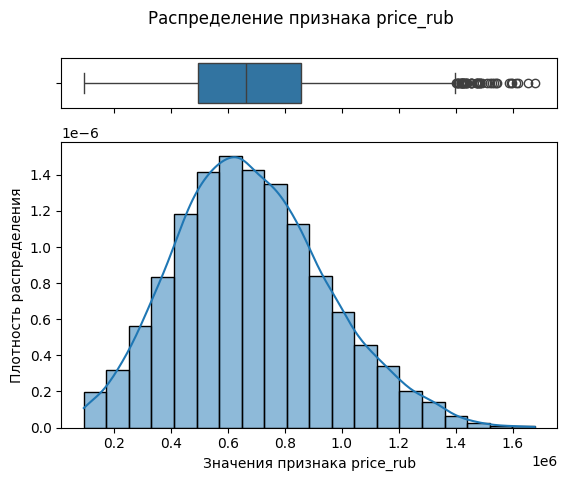

In [462]:
eda_helper.box_hist(df_train, TARGET_COL_NAME)

Распределение цены подержанных автомобилей близко к нормальному. Есть выбросы в правой части, но они органичны и связаны с дорогими автомобилями. Минимальная цена 95 тысяч рублей, максимальная - 1.6 млн рублей.

Цены выглядят подозрительно маленькими, вероятно датасет собран до 2020 года. Проверим это:

,count,mean,std,min,25%,50%,75%,max
make_year,8000.0,2009.22125,8.388703,1995.0,2002.0,2009.0,2017.0,2023.0


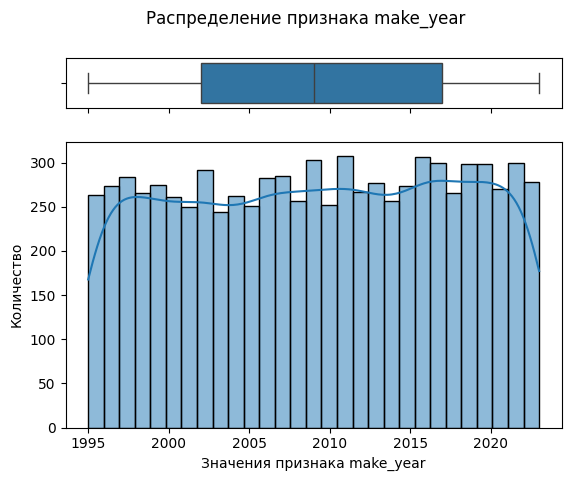

In [463]:
eda_helper.box_hist(df_train, 'make_year', bins=29, stat='count')

Действительно, даты производства автомобилей лежат в диапазоне 1995..2023. Количество автомобилей по годам имеет распределение близкое к равномерному (по 250 машин каждого года).

Сравним распределение целевой переменной в тестовой и тренировочной выборках:

,count,mean,std,min,25%,50%,75%,max
price_rub,2000.0,675791.9355,268019.598864,95000.0,481477.0,649284.0,845969.5,1629774.0


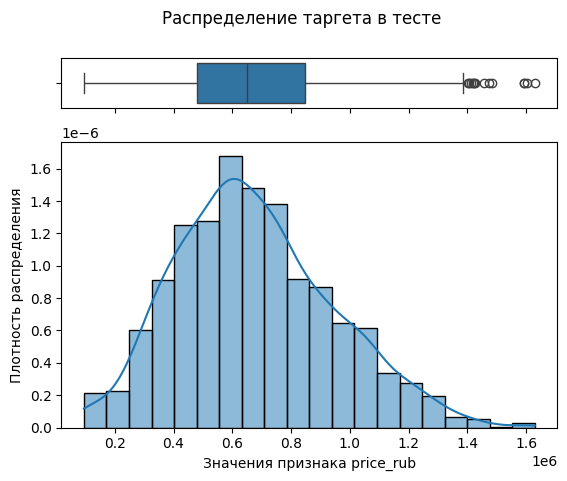

In [464]:
eda_helper.box_hist(df_test, TARGET_COL_NAME, title='Распределение таргета в тесте')

Распределение целевой переменной в тесте соответствует трейну.

### Корреляционный анализ

Построим матрицу корреляций.

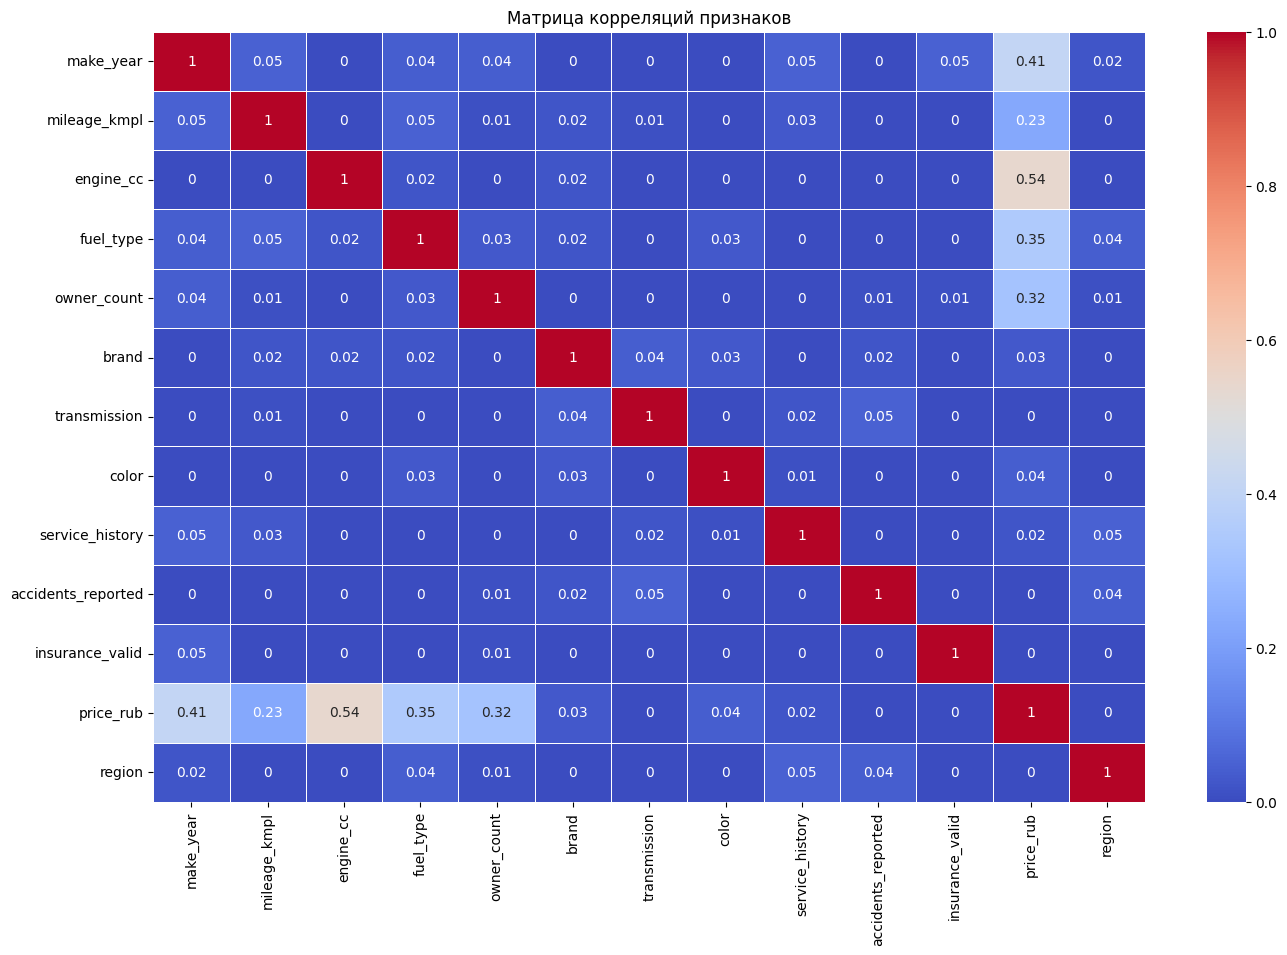

In [465]:
full_corr_matrix = df_train.phik_matrix(interval_cols=['mileage_kmpl', 'engine_cc', 'price_rub'])
corr_displayer = CorrelationDisplayer(full_corr_matrix)
corr_displayer.draw_corr_matrix_full()

Большинство признаков мало коррелируют друг с другом и целевой переменной, но есть явные фавориты в корреляции: объем двигателя c годом производства (средняя корреляция), а также пробег, тип топлива, количество владельцев с умеренной корреляцией.

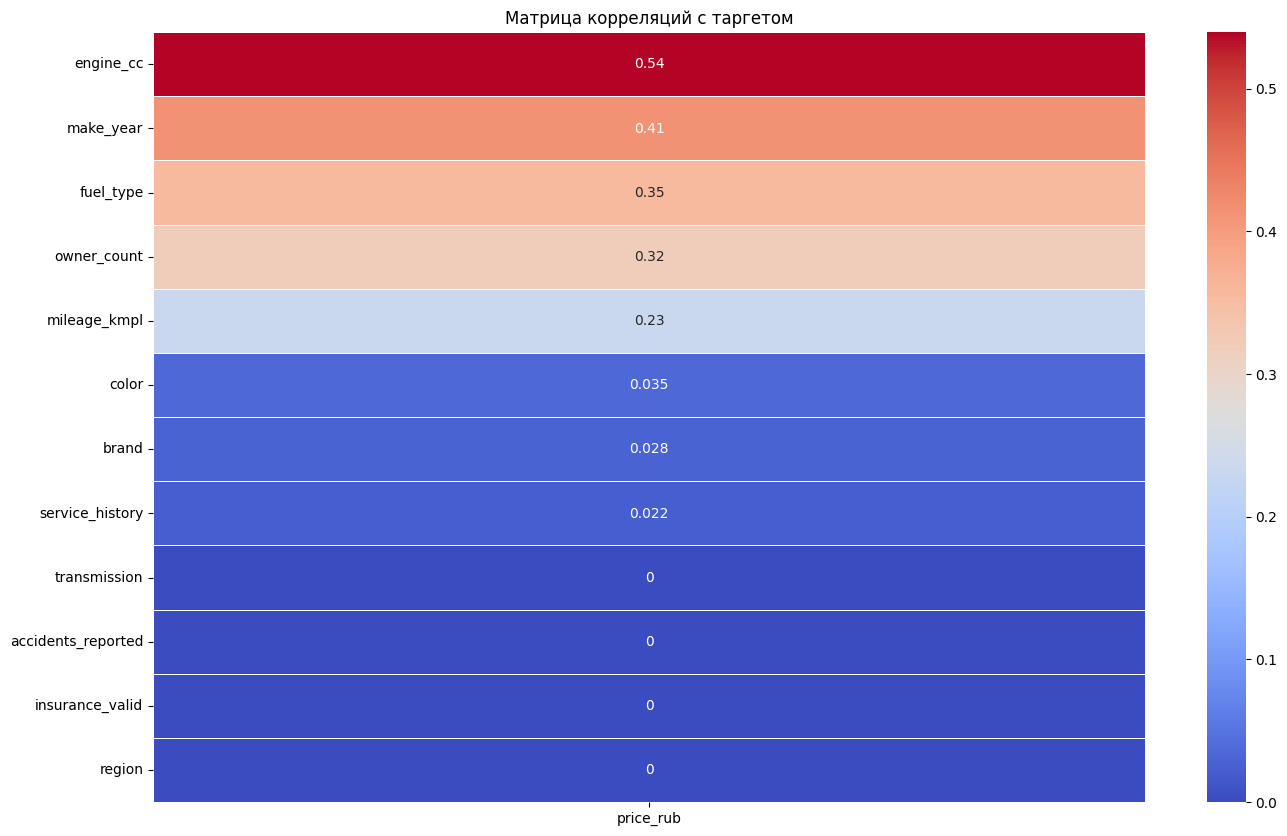

In [466]:
corr_displayer.draw_corr_matrix_with_target(TARGET_COL_NAME)

### Вывод по EDA

В результате экспресс EDA были загружены и проанализированы тренировочная и тестовая выборка датасетс с автомобильными ценами. Цена автомобиля имеет одинаковое близкое к нормальному распределение в обеих выборках. Специальной обработки выбросов не требуется. Пропуски отсутствуют.

Корреляционный анализ показал среднюю корреляцию с мощьностью двигателя и годом производства. У признаков тип топлива, количество владельцев и пробег - умеренная корреляция.

<a id="preprocessing"></a>

# **Часть 2. Предобработка**

На этом этапе подготовьте данные для честного соревнования библиотек. Помните: качество входных данных определяет предел точности самого мощного алгоритма.

**Задание 2.1:**

* Создайте одинаковые обучающие и валидационные наборы данных для всех трех библиотек.
* Подготовьте признаки для каждой библиотеки.
* Зафиксируйте тест: используйте файл `ds_s16_test_data.csv` как отложенную тестовую выборку.

Разделим матрицу признаков и целевую переменную:

In [467]:
X_train = df_train.drop(columns=[TARGET_COL_NAME])
y_train = df_train[TARGET_COL_NAME]

print(f'Размеры обучающей выборки: X_train={X_train.shape}, y_train={y_train.shape}')

Размеры обучающей выборки: X_train=(8000, 12), y_train=(8000,)


Построим пайплайны обучения трех моделей XGBoost, CatBoost, LightGBM для того чтобы сравнить их производительность. Для обучения будем использовать кросс-валидацию, так как с ее помощью не потребуется выделять отдельные выборки для обучения и валидации.

In [468]:
OHE_FEATURES = [
    'fuel_type',
    'transmission',
    'color',
    'service_history',
    'insurance_valid',
    'region',
]

ORDINAL_FEATURES = [
    'brand',
]

NUMERICAL_FEATURES = [
    'make_year',
    'mileage_kmpl',
    'engine_cc',
    'owner_count',
    'accidents_reported',
]
CAT_FEATURES = OHE_FEATURES + ORDINAL_FEATURES
ALL_FEATURES = CAT_FEATURES + NUMERICAL_FEATURES

DEFAULT_MODEL_PARAMS = {
    'random_state' : RANDOM_STATE
}
# определим трансформер для НЕ-катбустовых моделей
non_cbm_transformer = ColumnTransformer(
    transformers=[
        ('ohe', OneHotEncoder(), OHE_FEATURES),
        ('ordinal', OrdinalEncoder(), ORDINAL_FEATURES),
    ],
    remainder='passthrough',
)
def xgboost_pipe(model_params: dict = {}):
    model_params = DEFAULT_MODEL_PARAMS | model_params
    return Pipeline([
        ('transformer', non_cbm_transformer),
        ('model', XGBRegressor(**model_params))
    ])

def lgbm_pipe(model_params: dict = {}):
    model_params = DEFAULT_MODEL_PARAMS | model_params | {'verbosity':-1}
    return Pipeline([
        ('transformer', non_cbm_transformer),
        ('model', LGBMRegressor(**model_params))
    ])

def catboost_pipe(model_params: dict = {}):
    model_params = DEFAULT_MODEL_PARAMS | model_params | {'verbose': False}
    return CatBoostRegressor(**model_params)

pipelines = {
    'lgbm': {'model': lgbm_pipe()},
    'xgboost': {'model': xgboost_pipe()},
    'catboost': {
        'model': catboost_pipe(),
        'fit_params': {'cat_features': CAT_FEATURES},
    }
}

# Опредлим прараметры кросс-валидации
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

<a id="baseline_models"></a>

# **Часть 3. Обучение моделей в разных библиотеках**

Проверьте, как алгоритмы работают из коробки. Это покажет их естественную предрасположенность к вашему набору данных до начала тонкой настройки.

**Задание 3.1:**

* Обучите XGBoost, CatBoost и LightGBM на стандартных настройках.
* Установите для всех моделей `random_state=42`. В качестве целевой функции используйте MAE.
* Обучите каждую модель
* Задача со звёздочкой: замерьте время обучения и предсказания (Wall time) с помощью `%%time` или модуля `time`.

**Задание 3.2: Сравнение метрик**

* Рассчитайте математические метрики: MAE, RMSE, $R^2$.
* Рассчитайте бизнес-риски: Overpricing Rate (>20%) и Underpricing Loss (>20%).
* Сформулируйте гипотезу: какая библиотека на этом этапе кажется наиболее безопасной для бюджета компании?

**Задача со звёздочкой: модель с использованием Quantile Loss (квантильной регрессии) в CatBoost**

Что нужно сделать:

* Выберите библиотеку `CatBoost`. Реализуйте осторожную модель через квантильный лосс.
* Вместо стандартной функции потерь (MAE) установите `loss_function='Quantile'`.
* Настройте параметр квантиля. Достаточно при инициализации модели указать: `'Quantile:alpha=значение'`. Протестируйте разные значения, выберите оптимальное.
* Сравните результаты этой осторожной модели с базовой (обученной с помощью MAE):
  1. Насколько снизился Overpricing Rate?
  2. Насколько при этом вырос Underpricing Loss?
  3. Готовы ли вы рекомендовать такую безопасную модель Артёму (CEO) вместо самой точной базовой (обученной с помощью MAE)?

---

In [469]:
model_train_helper = ModelTrainHelper()
scoring = ['neg_mean_absolute_error', 'neg_mean_squared_error', 'r2']

metrics = model_train_helper.do_cross_validation(pipelines, X_train, y_train, scoring, return_train_score=True, cv=cv)

/Users/ngsmirnov/nikki/projects/practicum/sprint16_lightgbm_xgboost_cb_autoprice/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/ngsmirnov/nikki/projects/practicum/sprint16_lightgbm_xgboost_cb_autoprice/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/ngsmirnov/nikki/projects/practicum/sprint16_lightgbm_xgboost_cb_autoprice/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/ngsmirnov/nikki/projects/practicum/sprint16_lightgbm_xgboost_cb_autoprice/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but L

Обучение "lgbm" заняло 2.55 секунд
Обучение "xgboost" заняло 0.31 секунд
Обучение "catboost" заняло 5.09 секунд


In [470]:
metrics.round(2)

,mean_absolute_error,mean_squared_error,r2,wall_time_sec
model_name,,,,
xgboost (train),38357.17,2.515177e+09,0.96,0.31
lgbm (train),64392.32,6.560694e+09,0.91,2.55
catboost (train),70447.94,7.835288e+09,0.89,5.09
catboost,76971.15,9.340907e+09,0.87,5.09
lgbm,78930.23,9.839831e+09,0.86,2.55
xgboost,84175.29,1.120489e+10,0.84,0.31


В версии "из коробки" побеждает CatBoost с MAE=76971. Эта же модель показывает лучшую обобщающую способность, так как на валидации качество близко к трейну. Сильнее всех переобучается xgboost - он теряет в качестве на валидации почти в 2 раза. Модель LGBM показывает средние результаты на валидации 78930 и имеет склонность к переобучению.

Скорость обучения распределилась в обратном порядке по отношению к качеству. Быстрее всех обучается xgboost менее секунды. Модель lgbm обучается около 2-3 секунд, CatBoost - 5-6 секунд.

<a id="tuning"></a>

# **Часть 4. Работа с параметрами модели (Тюнинг)**

Теперь ваша задача — заставить алгоритмы работать на пределе возможностей, подбирая ключи к их гиперпараметрам. Чтобы сравнение было объективным, используйте единую стратегию поиска для всех библиотек.

**Задание 4.1:**

* Настройте поиск в Optuna для каждой модели.
* Использьзуйте сетку параметров, предложенную в описании проекта:
  1. **Общая сетка для всех моделей:**
    * Скорость обучения (`learning_rate/eta`): от `0.01` до `0.1, log=True`.
    * Глубина дерева (`max_depth/depth`): от `3` до `10`.
    * Количество итераций (`n_estimators/iterations`): зафиксируйте в диапазоне `500–2000`.
  2. **Специфические параметры (регуляризация):**
  * Для XGBoost: добавьте параметры `gamma` (от `1e-8` до `1.0`) и `reg_lambda/reg_alpha`(от `1e-8` до `10.0`).
  * Для CatBoost: используйте `l2_leaf_reg` (от `1` до `10`).
  * Для LightGBM: добавьте `num_leaves` (от `20` до `256`) и `min_child_samples` (от `5` до `100`); `reg_alpha` и `reg_lambda` от `1e-8` до `1.0`.
  3. Не забудьте `"random_seed": 42` и `MAE` .

* Проведите поиск гиперпараметров с помощью Optuna.
---


Найдем оптимальные параметры моделей с помощью библиотеки Optuna:

In [519]:
optuna_helper = OptunaHelper(X_train, y_train, cv)
scorer_func = make_scorer(mean_absolute_error, greater_is_better=False)

In [520]:
def lightgbm_params_func(trial):
    return {
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'n_estimators': trial.suggest_int('n_estimators', 500, 2000),
        'num_leaves': trial.suggest_int('num_leaves', 2, 256),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 1.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 1.0),
    }

def lightgbm_estimator_func(params):
    return lgbm_pipe(params)

lightgbm_study = optuna_helper.fit_study(
    lightgbm_params_func, lightgbm_estimator_func, scorer_func, n_trials=10, visualize=True)

print('=== LightGBM ===')
print('Наилучшие гиперпараметры:', lightgbm_study.best_params)
print(f'MAE: {-lightgbm_study.best_value:.2f}')

[I 2026-05-21 21:28:11,877] A new study created in memory with name: no-name-1e68e310-31ad-465e-8e8e-674e0ab84f8f
/Users/ngsmirnov/nikki/projects/practicum/sprint16_lightgbm_xgboost_cb_autoprice/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/ngsmirnov/nikki/projects/practicum/sprint16_lightgbm_xgboost_cb_autoprice/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/ngsmirnov/nikki/projects/practicum/sprint16_lightgbm_xgboost_cb_autoprice/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/ngsmirnov/nikki/projects/practicum/sprint16_lightgbm_xgboost_cb_autoprice/.venv/lib/

=== LightGBM ===
Наилучшие гиперпараметры: {'learning_rate': 0.015199348301309814, 'max_depth': 4, 'n_estimators': 956, 'num_leaves': 135, 'min_child_samples': 46, 'reg_alpha': 0.2912291472857505, 'reg_lambda': 0.6118528986038505}
MAE: 77792.81


In [525]:
model_train_helper.compare_metrics(78930, -lightgbm_study.best_value, "MAE", digits=0)

Улучшение метрики MAE: 78930->77793 (-1%)


Наилучшие гиперпараметры LightGBM: {
- 'learning_rate': 0.030529224555242575,
- 'max_depth': 3,
- 'n_estimators': 711,
- 'num_leaves': 131,
- 'min_child_samples': 21,
- 'reg_alpha': 0.28141426676481696,
- 'reg_lambda': 0.3583902912066392
}

MAE улучшилась после оптимизации: 78930->77793 (примерно на 1 п.п.)

Наибольший вклад в рост качества вложил гиперпараметр reg_alpha (L1-регуляризация)

In [473]:
def xgboost_params_func(trial):
    return {
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'n_estimators': trial.suggest_int('n_estimators', 500, 2000),
        'gamma': trial.suggest_float('gamma', 1e-8, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10),
    }

def xgboost_estimator_func(params):
    return xgboost_pipe(params)

xgboost_study = optuna_helper.fit_study(
    xgboost_params_func, xgboost_estimator_func, scorer_func, n_trials=30, visualize=True)

print('=== xgboost ===')
print('Наилучшие гиперпараметры:', xgboost_study.best_params)
print(f'MAE: {-xgboost_study.best_value:.2f}')

[I 2026-05-21 20:22:26,629] A new study created in memory with name: no-name-36a19a5d-c3f5-4391-8e77-2d735fe1cb49
[I 2026-05-21 20:22:55,590] Trial 0 finished with value: -84669.728125 and parameters: {'learning_rate': 0.023688639503640783, 'max_depth': 10, 'n_estimators': 1598, 'gamma': 0.5986584882104518, 'reg_alpha': 1.5601864128641787, 'reg_lambda': 1.5599452118020811}. Best is trial 0 with value: -84669.728125.
[I 2026-05-21 20:23:16,288] Trial 1 finished with value: -82377.69375 and parameters: {'learning_rate': 0.011430983876313222, 'max_depth': 9, 'n_estimators': 1402, 'gamma': 0.7080725807153196, 'reg_alpha': 0.2058449527521795, 'reg_lambda': 9.699098521920844}. Best is trial 1 with value: -82377.69375.
[I 2026-05-21 20:23:21,005] Trial 2 finished with value: -79942.06875 and parameters: {'learning_rate': 0.06798962421591129, 'max_depth': 4, 'n_estimators': 772, 'gamma': 0.1834045180193887, 'reg_alpha': 3.0424224365529544, 'reg_lambda': 5.2475643210748135}. Best is trial 2 wit

=== xgboost ===
Наилучшие гиперпараметры: {'learning_rate': 0.014190835536659665, 'max_depth': 3, 'n_estimators': 991, 'gamma': 0.8508917982233571, 'reg_alpha': 4.230819137897658, 'reg_lambda': 4.314078392249338}
MAE: 77225.53


In [ ]:
model_train_helper.compare_metrics(84175, -xgboost_study.best_value, "MAE", digits=0)

Улучшение метрики MAE: 84175->77226 (-8%)


Наилучшие гиперпараметры XGBoost: {
- 'learning_rate': 0.014190835536659665,
- 'max_depth': 3,
- 'n_estimators': 991,
- 'gamma': 0.8508917982233571,
- 'reg_alpha': 4.230819137897658,
- 'reg_lambda': 4.314078392249338
}

MAE улучшился на 8%: 84175->77226

In [486]:
def catboost_params_func(trial):
    return {
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'n_estimators': trial.suggest_int('n_estimators', 500, 2000),
        'l2_leaf_reg': trial.suggest_int('l2_leaf_reg', 1, 10),
    }

def catboost_estimator_func(params):
    return catboost_pipe(params)

catboost_study = optuna_helper.fit_study(
    catboost_params_func, catboost_estimator_func, scorer_func, n_trials=30, visualize=True, fit_params={'cat_features': CAT_FEATURES})

print('=== catboost ===')
print('Наилучшие гиперпараметры:', catboost_study.best_params)
print(f'MAE: {-catboost_study.best_value:.2f}')

[I 2026-05-21 20:39:30,535] A new study created in memory with name: no-name-ef308063-f122-42fb-82ba-b956108684da
[I 2026-05-21 20:39:55,879] Trial 0 finished with value: -77677.22366245843 and parameters: {'learning_rate': 0.023688639503640783, 'max_depth': 10, 'n_estimators': 1598, 'l2_leaf_reg': 6}. Best is trial 0 with value: -77677.22366245843.
[I 2026-05-21 20:39:58,803] Trial 1 finished with value: -76782.54618785705 and parameters: {'learning_rate': 0.014322493718230255, 'max_depth': 4, 'n_estimators': 587, 'l2_leaf_reg': 9}. Best is trial 1 with value: -76782.54618785705.
[I 2026-05-21 20:40:03,491] Trial 2 finished with value: -77052.65998963613 and parameters: {'learning_rate': 0.039913058785616795, 'max_depth': 8, 'n_estimators': 530, 'l2_leaf_reg': 10}. Best is trial 1 with value: -76782.54618785705.
[I 2026-05-21 20:40:06,363] Trial 3 finished with value: -76510.87524890635 and parameters: {'learning_rate': 0.06798962421591129, 'max_depth': 4, 'n_estimators': 772, 'l2_lea

=== catboost ===
Наилучшие гиперпараметры: {'learning_rate': 0.020165721691808594, 'max_depth': 3, 'n_estimators': 1527, 'l2_leaf_reg': 5}
MAE: 76276.03


In [489]:
model_train_helper.compare_metrics(76971, -catboost_study.best_value, "MAE", digits=0)

Улучшение метрики MAE: 76971->76276 (-1%)


Наилучшие гиперпараметры CatBoost: {
- 'learning_rate': 0.020165721691808594,
- 'max_depth': 3,
- 'n_estimators': 1527,
- 'l2_leaf_reg': 5
}

МАЕ улучшилась 76971->76276 на 1%

Сравним результаты моделей:

In [497]:
pd.DataFrame([
    {'model': 'lightgbm', 'MAE': -lightgbm_study.best_value},
    {'model': 'catboost', 'MAE': -catboost_study.best_value},
    {'model': 'xgboost', 'MAE': -xgboost_study.best_value},
]).sort_values(by='MAE').reset_index(drop=True).round(0)

,model,MAE
0,catboost,76276.0
1,xgboost,77226.0
2,lightgbm,77342.0


После оптимизации гиперпараметров, все модели почти сравнялись в метрике MAE и ошибаются в среднем на 76-77 тысяч рублей. Чуть лучше выглядит CatBoost с MAE=76000.

<a id="interpretation"></a>

# **Часть 5. Интерпретация и бизнес-анализ**

Модель должна быть прозрачной. Ваша задача — убедиться, что алгоритм принимает решения на основе рыночных факторов, а не случайных корреляций.

**Задание 5.1:**

* Постройте SHAP Summary Plot для оптимизированных моделей после поиска Optuna.
* Проанализируйте:
  1. Какие Топ-5 признаков вносят наибольший вклад в цену автомобиля?
  2. Совпадают ли выводы модели с бизнес-логикой?
  3. Как специфические признаки (например, color или insurance_valid) влияют на предсказание?

**Задание 5.2**

Используйте введённые метрики Overpricing Rate и Underpricing Loss:
* Рассчитайте долю завышений и недооценок для каждой модели.
* Сравните модели не только по MAE и RMSE, но и по бизнес-рискам.

**Задание 5.3**

* Проанализируйте ошибки в разрезе категорий (марки автомобилей и макро-регионов).
* Выявите марки машин и регионы, где риск ошибки высок — это зоны, где в будущем потребуется ручная проверка экспертом.

---

In [ ]:
lightgbm_optimized = lgbm_pipe(**lightgbm_study.best_params)
lightgbm_optimized.fit(X_train, y_train)

In [531]:
# Создаём explainer и вычисляем SHAP-значения
explainer = shap.TreeExplainer(lightgbm_study.best_estimator)
shap_values = explainer.shap_values(X_test)

# Summary Plot для всех признаков
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test, show=False)
plt.title("SHAP Summary Plot", fontsize=16)
plt.tight_layout()
plt.show()

AttributeError: 'Study' object has no attribute 'best_estimator'

<a id="final_test"></a>

# **Часть 6. Финальная проверка**

Момент истины. На этом этапе вы должны подтвердить надежность выбранного решения на данных, которые модель никогда не видела, и дать обоснованную рекомендацию бизнесу.

**Задание 6.1**

* Выберите лучшую модель и прогоните её через `ds_s16_test_data.csv`.
* Сформируйте итоговый результат на тестовой выборке. Проверьте, нет ли переобучения.

<a id="conclusion"></a>

 # **Часть 7. Описание выводов и финальный вердикт**

**Задание 7.1**

Заполните краткую аналитическую записку на основе ваших данных.

**АНАЛИТИЧЕСКАЯ ЗАПИСКА ПО ПРОЕКТУ AUTOVALUE AI:**

1. Рекомендованная модель: [Название вашей лучшей модели, например]

2. Точность оценки: в среднем модель ошибается на [Ваше MAE] руб. Коэффициент детерминации равен[Ваше $R^2$], что подтверждает высокую надёжность прогнозов.

3. Безопасность бюджета: риск опасной переплаты (Overpricing >20%) зафиксирован на уровне [Ваш %]. Это позволяет стартапу сохранять маржинальность при выкупе.

4. Упущенная выгода: можем терять до [Сумма Underpricing Loss] руб. в месяц из-за занижения цены. Рекомендуется ручной пересмотр для премиум-сегмента.

5. Зоны риска: модель наиболее нестабильна в регионе [Ваш проблемный регион] и на марках [Ваши проблемные марки].

6. Какие гиперпараметры следует зафиксировать для интеграции в мобильное приложение.

---